In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
data=pd.read_csv('/kaggle/input/churn-bank-customer/Churn_Modelling.csv')
data

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/churn-bank-customer/Churn_Modelling.csv'

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
data.duplicated().sum()

0

In [ ]:
data = data.drop(columns=['RowNumber', 'CustomerId', 'Surname'])


In [ ]:
data['Geography'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [ ]:
data = pd.get_dummies(
    data,
    columns=['Geography', 'Gender'],
    drop_first=True
)


In [ ]:
data

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,0,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,1,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,1,True,False,True


In [ ]:
cols = ['Geography_Germany', 'Geography_Spain', 'Gender_Male']
data[cols] = data[cols].astype(int)


In [ ]:
data['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

                   CreditScore       Age    Tenure   Balance  NumOfProducts  \
CreditScore           1.000000 -0.003965  0.000842  0.006268       0.012238   
Age                  -0.003965  1.000000 -0.009997  0.028308      -0.030680   
Tenure                0.000842 -0.009997  1.000000 -0.012254       0.013444   
Balance               0.006268  0.028308 -0.012254  1.000000      -0.304180   
NumOfProducts         0.012238 -0.030680  0.013444 -0.304180       1.000000   
HasCrCard            -0.005458 -0.011721  0.022583 -0.014858       0.003183   
IsActiveMember        0.025651  0.085472 -0.028362 -0.010084       0.009612   
EstimatedSalary      -0.001384 -0.007201  0.007784  0.012797       0.014204   
Exited               -0.027094  0.285323 -0.014001  0.118533      -0.047820   
Geography_Germany     0.005538  0.046897 -0.000567  0.401110      -0.010419   
Geography_Spain       0.004780 -0.001685  0.003868 -0.134892       0.009039   
Gender_Male          -0.002857 -0.027544  0.014733  

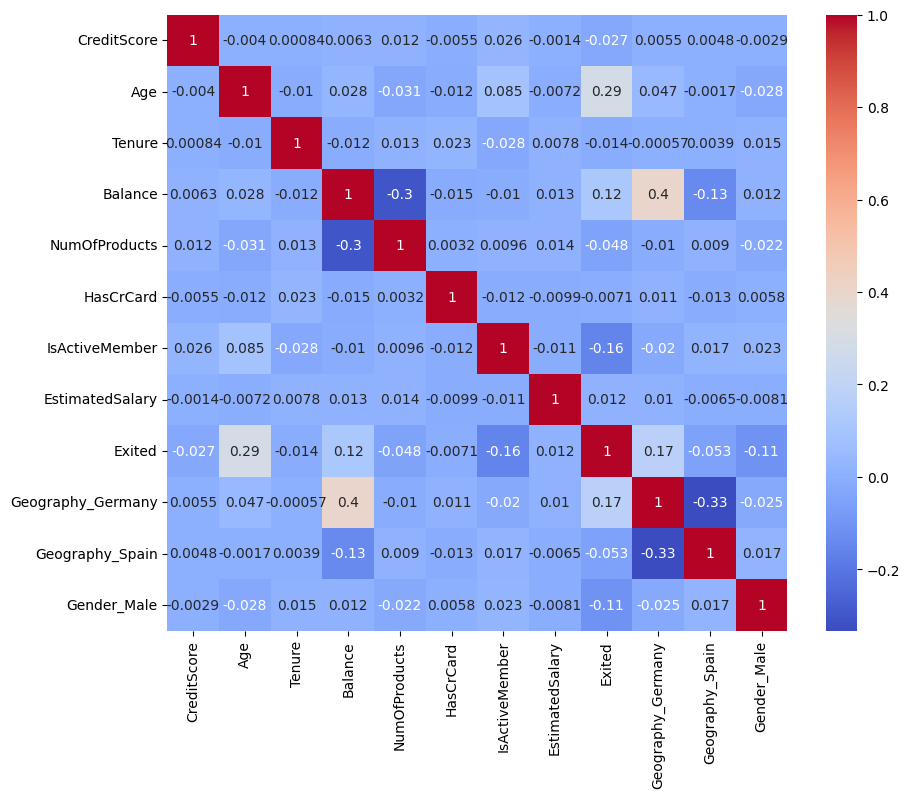

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = data.corr()

print(corr_matrix)

# visualize it
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()


**We can see from here there is no strong correlation between features and target so i think the models that depend on linearity not give the best results needed. (Logistic and polynomial not expect give the best)**

## Splitting Data

In [ ]:
x=data.drop(columns=['Exited'])
y=data['Exited']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

## Logistic Regression (Imbalanced Data)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
model1=LogisticRegression()
model1.fit(x_train_scaled,y_train)

LogisticRegression()

## Evaluation

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
y_pred = model1.predict(x_test_scaled)
print( accuracy_score(y_test, y_pred))
print(f1_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(recall_score(y_test, y_pred))

0.811
0.2947761194029851
0.5524475524475524
0.2010178117048346


In [ ]:
print("Training",model1.score(x_train_scaled,y_train))
print("Testing",model1.score(x_test_scaled,y_test))

Training 0.811375
Testing 0.811


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix
y_predict=model1.predict(x_test_scaled)


In [ ]:
from sklearn.metrics import classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[1543   64]
 [ 314   79]]
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



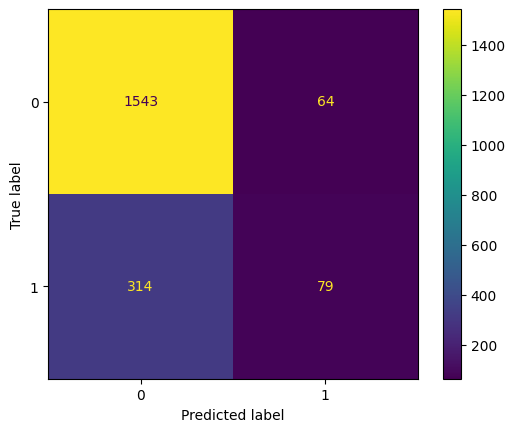

In [ ]:
import matplotlib.pyplot as plt
cm=confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()


## SMOTE + logisticRegression

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2,stratify=y)

In [ ]:
pip install scikit-learn==1.2.2 imbalanced-learn==0.10.1

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()
x_train_resampled_smote, y_train_resampled_smote = smote.fit_resample(x_train, y_train)

In [ ]:
x_train_scaled=scaler.fit_transform(x_train_resampled_smote)
x_test_scaled=scaler.transform(x_test)
## Logistic Regression
model2=LogisticRegression(random_state=42)
model2.fit(x_train_scaled,y_train_resampled_smote)

##Accuracy
print('Training accuracy',model2.score(x_train_scaled,y_train_resampled_smote))
print("Testing accuracy",model2.score(x_test_scaled,y_test))

Training accuracy 0.7781004709576138
Testing accuracy 0.732


## Evaluation (SMOTE) with Logistic Regression

In [ ]:
y_pred = model2.predict(x_test_scaled)
cm=confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred))


[[1222  371]
 [ 165  242]]
              precision    recall  f1-score   support

           0       0.88      0.77      0.82      1593
           1       0.39      0.59      0.47       407

    accuracy                           0.73      2000
   macro avg       0.64      0.68      0.65      2000
weighted avg       0.78      0.73      0.75      2000



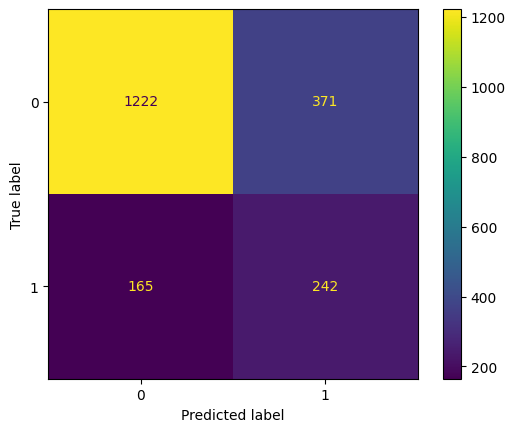

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()


| Model                       | Class | TP   | FP  | FN  | TN   | Precision | Recall | F1-score | Support |
| --------------------------- | ----- | ---- | --- | --- | ---- | --------- | ------ | -------- | ------- |
| Logistic Regression         | 0     | 1543 | 64  | 314 | 79   | 0.83      | 0.96   | 0.89     | 1607    |
|                             | 1     | 79   | 314 | 64  | 1543 | 0.55      | 0.20   | 0.29     | 393     |
| Logistic Regression + SMOTE | 0     | 1222 | 371 | 165 | 242  | 0.88      | 0.77   | 0.82     | 1593    |
|                             | 1     | 242  | 165 | 371 | 1222 | 0.39      | 0.59   | 0.47     | 407     |


## Difference when resample all data not only train data

In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()
x_new, y_new = smote.fit_resample(x, y)

In [ ]:
x_train_new, x_test_new, y_train_new, y_test_new = train_test_split(x_new, y_new, test_size=0.2, random_state=42)

In [ ]:
x_train_scaled=scaler.fit_transform(x_train_new)
x_test_scaled=scaler.transform(x_test_new)
## Logistic Regression
model3=LogisticRegression(random_state=42)
model3.fit(x_train_scaled,y_train_new)

##Accuracy
print('Training accuracy',model2.score(x_train_scaled,y_train_new))
print("Testing accuracy",model2.score(x_test_scaled,y_test_new))

Training accuracy 0.777629513343799
Testing accuracy 0.7862523540489642


In [ ]:
y_pred = model3.predict(x_test_scaled)
cm=confusion_matrix(y_test_new, y_pred)
print(cm)
print(classification_report(y_test_new, y_pred))


[[1269  364]
 [ 309 1244]]
              precision    recall  f1-score   support

           0       0.80      0.78      0.79      1633
           1       0.77      0.80      0.79      1553

    accuracy                           0.79      3186
   macro avg       0.79      0.79      0.79      3186
weighted avg       0.79      0.79      0.79      3186



## Polynomial

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2,stratify=y)

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

poly_log_reg = Pipeline(steps=[
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("log_reg", LogisticRegression(max_iter=1000))
])

# fit
poly_log_reg.fit(x_train, y_train)

# predict
y_pred = poly_log_reg.predict(x_test)

# accuracy
print("Testing accuracy",poly_log_reg.score(x_test, y_test))
print("Training accuracy",poly_log_reg.score(x_train, y_train))



Testing accuracy 0.8625
Training accuracy 0.858125


## Evaluation (Polynomial+Imbalanced Data)

In [ ]:

print( accuracy_score(y_test, y_pred))
print(f1_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(recall_score(y_test, y_pred))

0.8625
0.5669291338582676
0.7894736842105263
0.44226044226044225


In [ ]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1545   48]
 [ 227  180]]
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.79      0.44      0.57       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.74      2000
weighted avg       0.86      0.86      0.85      2000



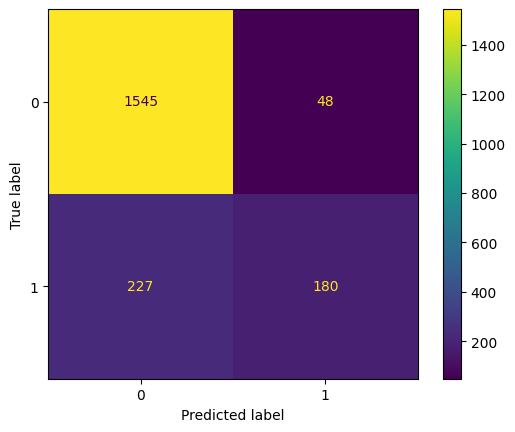

In [ ]:
cm=confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()


## SMOTE + Polynomial

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2,stratify=y)

In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()
x_train_resampled_smote, y_train_resampled_smote = smote.fit_resample(x_train, y_train)

In [ ]:
x_train_scaled=scaler.fit_transform(x_train_resampled_smote)
x_test_scaled=scaler.transform(x_test)

poly_log_reg = Pipeline(steps=[
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("log_reg", LogisticRegression(max_iter=1000))
])

# fit
poly_log_reg.fit(x_train_scaled, y_train_resampled_smote)

# predict
y_pred = poly_log_reg.predict(x_test_scaled)

# accuracy
print("Testing accuracy",poly_log_reg.score(x_test_scaled, y_test))
print("Training accuracy",poly_log_reg.score(x_train_scaled, y_train_resampled_smote))



Testing accuracy 0.793
Training accuracy 0.8273940345368916


In [ ]:

cm=confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred))


[[1313  280]
 [ 134  273]]
              precision    recall  f1-score   support

           0       0.91      0.82      0.86      1593
           1       0.49      0.67      0.57       407

    accuracy                           0.79      2000
   macro avg       0.70      0.75      0.72      2000
weighted avg       0.82      0.79      0.80      2000



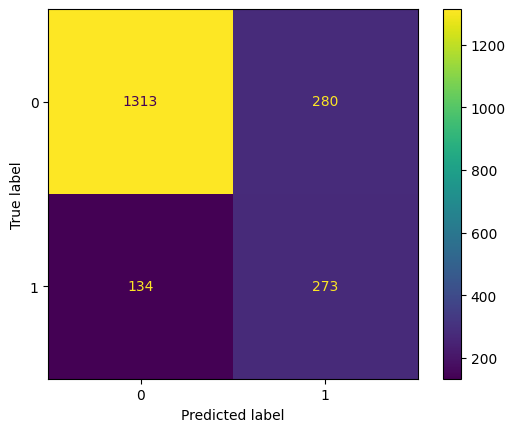

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()


| Model                       | Class | TP   | FP  | FN  | TN   | Precision | Recall | F1-score | Support |
| --------------------------- | ----- | ---- | --- | --- | ---- | --------- | ------ | -------- | ------- |
| Polynomial Logistic         | 0     | 1545 | 48  | 227 | 180  | 0.87      | 0.97   | 0.92     | 1593    |
|                             | 1     | 180  | 227 | 48  | 1545 | 0.79      | 0.44   | 0.57     | 407     |
| Polynomial Logistic + SMOTE | 0     | 1313 | 280 | 134 | 273  | 0.91      | 0.82   | 0.86     | 1593    |
|                             | 1     | 273  | 134 | 280 | 1313 | 0.49      | 0.67   | 0.57     | 407     |


## SVC

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:

x_train = scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [ ]:
from sklearn.svm import SVC
model4 = SVC()
model4.fit(x_train, y_train)

SVC()

In [ ]:
print("Training accuracy:",model4.score(x_train, y_train))
print("Testing accuracy:",model4.score(x_test, y_test))

Training accuracy: 0.865
Testing accuracy: 0.861


## Evaluation (SCV+Imbalanced Data)

In [ ]:
y_pred=model4.predict(x_test)
cm=confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred))


[[1561   32]
 [ 246  161]]
              precision    recall  f1-score   support

           0       0.86      0.98      0.92      1593
           1       0.83      0.40      0.54       407

    accuracy                           0.86      2000
   macro avg       0.85      0.69      0.73      2000
weighted avg       0.86      0.86      0.84      2000



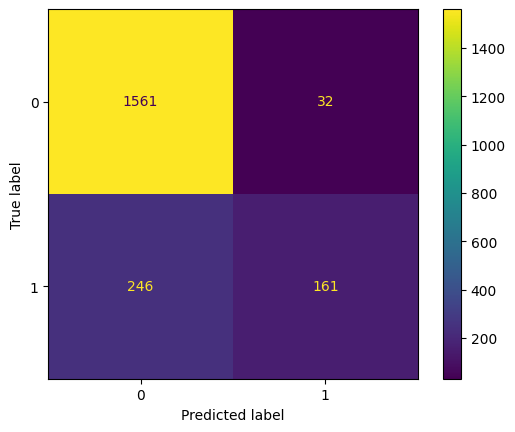

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()


## SMOTE + SVC 

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2,stratify=y)
smote = SMOTE()
x_train_resampled_smote, y_train_resampled_smote = smote.fit_resample(x_train, y_train)

In [ ]:
x_train_scaled=scaler.fit_transform(x_train_resampled_smote)
x_test_scaled=scaler.transform(x_test)

model5=SVC(random_state=42)
model5.fit(x_train_scaled,y_train_resampled_smote)

##Accuracy
print('Training accuracy',model5.score(x_train_scaled,y_train_resampled_smote))
print("Testing accuracy",model5.score(x_test_scaled,y_test))

Training accuracy 0.847331240188383
Testing accuracy 0.797


## Evaluation (SCV+SMOTE)

In [ ]:
y_pred=model5.predict(x_test_scaled)
cm=confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred))


[[1320  273]
 [ 133  274]]
              precision    recall  f1-score   support

           0       0.91      0.83      0.87      1593
           1       0.50      0.67      0.57       407

    accuracy                           0.80      2000
   macro avg       0.70      0.75      0.72      2000
weighted avg       0.83      0.80      0.81      2000



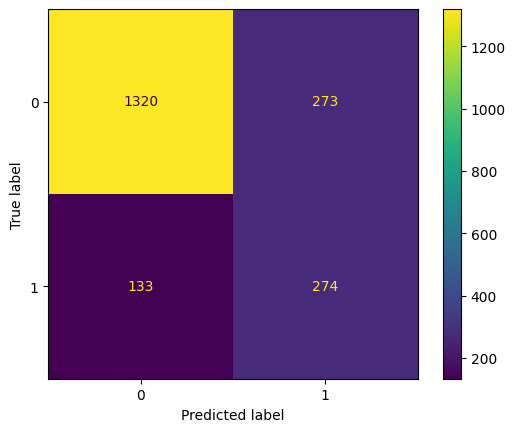

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()


| Model                       | Class | TP   | FP  | FN  | TN   | Precision | Recall | F1-score | Support |
| --------------------------- | ----- | ---- | --- | --- | ---- | --------- | ------ | -------- | ------- |
| Logistic Regression         | 0     | 1543 | 64  | 314 | 79   | 0.83      | 0.96   | 0.89     | 1607    |
|                             | 1     | 79   | 314 | 64  | 1543 | 0.55      | 0.20   | 0.29     | 393     |
| Logistic Regression + SMOTE | 0     | 1222 | 371 | 165 | 242  | 0.88      | 0.77   | 0.82     | 1593    |
|                             | 1     | 242  | 165 | 371 | 1222 | 0.39      | 0.59   | 0.47     | 407     |
| Polynomial Logistic         | 0     | 1545 | 48  | 227 | 180  | 0.87      | 0.97   | 0.92     | 1593    |
|                             | 1     | 180  | 227 | 48  | 1545 | 0.79      | 0.44   | 0.57     | 407     |
| Polynomial Logistic + SMOTE | 0     | 1313 | 280 | 134 | 273  | 0.91      | 0.82   | 0.86     | 1593    |
|                             | 1     | 273  | 134 | 280 | 1313 | 0.49      | 0.67   | 0.57     | 407     |
| SVC                         | 0     | 1561 | 32  | 246 | 161  | 0.86      | 0.98   | 0.92     | 1593    |
|                             | 1     | 161  | 246 | 32  | 1561 | 0.83      | 0.40   | 0.54     | 407     |
| SVC + SMOTE                 | 0     | 1320 | 273 | 133 | 274  | 0.91      | 0.83   | 0.87     | 1593    |
|                             | 1     | 274  | 133 | 273 | 1320 | 0.50      | 0.67   | 0.57     | 407     |


## DTC (imbalanced data)

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2,stratify=y)
from sklearn.tree import DecisionTreeClassifier
model6 = DecisionTreeClassifier()
model6.fit(x_train, y_train)

DecisionTreeClassifier()

In [ ]:
print("Training accuracy:",model6.score(x_train, y_train))
print("Testing accuracy:",model6.score(x_test, y_test))

Training accuracy: 1.0
Testing accuracy: 0.786


**overfitting problem**

## Evaluation (DTC +Imbalanced Data)

In [ ]:
y_pred=model6.predict(x_test)
cm=confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred))


[[1365  228]
 [ 200  207]]
              precision    recall  f1-score   support

           0       0.87      0.86      0.86      1593
           1       0.48      0.51      0.49       407

    accuracy                           0.79      2000
   macro avg       0.67      0.68      0.68      2000
weighted avg       0.79      0.79      0.79      2000



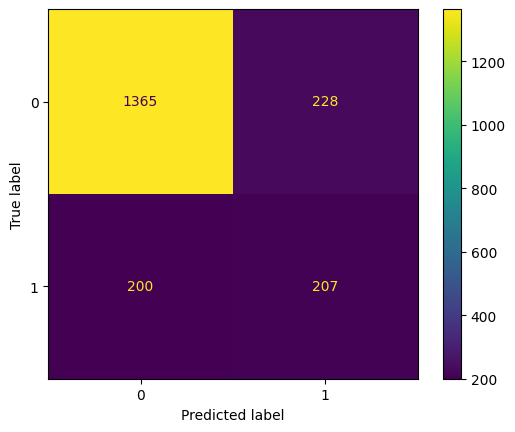

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

## DTC + SMOTE

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2,stratify=y)
smote = SMOTE()
x_train_resampled_smote, y_train_resampled_smote = smote.fit_resample(x_train, y_train)

In [ ]:
x_train_scaled=scaler.fit_transform(x_train_resampled_smote)
x_test_scaled=scaler.transform(x_test)

model7=DecisionTreeClassifier()
model7.fit(x_train_scaled,y_train_resampled_smote)

##Accuracy
print('Training accuracy',model7.score(x_train_scaled,y_train_resampled_smote))
print("Testing accuracy",model7.score(x_test_scaled,y_test))

Training accuracy 1.0
Testing accuracy 0.738


In [ ]:
y_pred=model7.predict(x_test_scaled)
cm=confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred))


[[1235  358]
 [ 166  241]]
              precision    recall  f1-score   support

           0       0.88      0.78      0.82      1593
           1       0.40      0.59      0.48       407

    accuracy                           0.74      2000
   macro avg       0.64      0.68      0.65      2000
weighted avg       0.78      0.74      0.75      2000



| Model       | Class | TP   | FP  | FN  | TN   | Precision | Recall | F1-score | Support |
| ----------- | ----- | ---- | --- | --- | ---- | --------- | ------ | -------- | ------- |
| DTC         | 0     | 1365 | 228 | 200 | 207  | 0.87      | 0.86   | 0.86     | 1593    |
|             | 1     | 207  | 200 | 228 | 1365 | 0.48      | 0.51   | 0.49     | 407     |
| DTC + SMOTE | 0     | 1235 | 358 | 166 | 241  | 0.88      | 0.78   | 0.82     | 1593    |
|             | 1     | 241  | 166 | 358 | 1235 | 0.40      | 0.59   | 0.48     | 407     |


## XGBoost 

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2,stratify=y)
from xgboost import XGBClassifier
model8 = XGBClassifier()
model8.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [ ]:
print("Training accuracy:",model8.score(x_train, y_train))
print("Testing accuracy:",model8.score(x_test, y_test))

Training accuracy: 0.9585
Testing accuracy: 0.853


## Evaluation (XGBoost)

In [ ]:
y_pred=model8.predict(x_test)
cm=confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred))


[[1506   87]
 [ 207  200]]
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      1593
           1       0.70      0.49      0.58       407

    accuracy                           0.85      2000
   macro avg       0.79      0.72      0.74      2000
weighted avg       0.84      0.85      0.84      2000



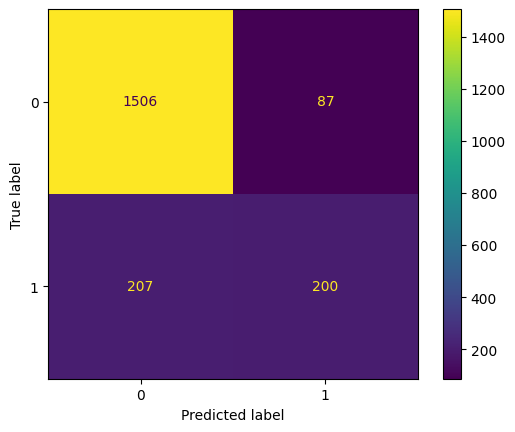

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

## XGBOOST + SMOTE

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2,stratify=y)
smote = SMOTE()
x_train_resampled_smote, y_train_resampled_smote = smote.fit_resample(x_train, y_train)

In [ ]:
x_train_scaled=scaler.fit_transform(x_train_resampled_smote)
x_test_scaled=scaler.transform(x_test)

model9=XGBClassifier()
model9.fit(x_train_scaled,y_train_resampled_smote)

##Accuracy
print('Training accuracy',model9.score(x_train_scaled,y_train_resampled_smote))
print("Testing accuracy",model9.score(x_test_scaled,y_test))

Training accuracy 0.9492150706436421
Testing accuracy 0.8105


In [ ]:
y_pred=model9.predict(x_test_scaled)
cm=confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred))


[[1359  234]
 [ 145  262]]
              precision    recall  f1-score   support

           0       0.90      0.85      0.88      1593
           1       0.53      0.64      0.58       407

    accuracy                           0.81      2000
   macro avg       0.72      0.75      0.73      2000
weighted avg       0.83      0.81      0.82      2000



| Model           | Class | TP   | FP  | FN  | TN   | Precision | Recall | F1-score | Support |
| --------------- | ----- | ---- | --- | --- | ---- | --------- | ------ | -------- | ------- |
| XGBoost         | 0     | 1506 | 87  | 207 | 200  | 0.88      | 0.95   | 0.91     | 1593    |
|                 | 1     | 200  | 207 | 87  | 1506 | 0.70      | 0.49   | 0.58     | 407     |
| XGBoost + SMOTE | 0     | 1359 | 234 | 145 | 262  | 0.90      | 0.85   | 0.88     | 1593    |
|                 | 1     | 262  | 145 | 234 | 1359 | 0.53      | 0.64   | 0.58     | 407     |


## EasyEnsembleClassifier 

In [ ]:
from imblearn.combine import SMOTETomek
smk = SMOTETomek(random_state=42)
x_res, y_res = smk.fit_resample(x, y)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x_res, y_res, test_size=0.2, random_state=42)

In [ ]:
from imblearn.ensemble import EasyEnsembleClassifier

eec = EasyEnsembleClassifier(random_state=42)
eec.fit(x_train, y_train)

EasyEnsembleClassifier(random_state=42)

In [ ]:
y_pred = eec.predict(x_test)

# Classification Report
print('Classification Report')
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

# Accuracy Score
print("Accuracy Score")
print("Testing accuracy",eec.score(x_test, y_test))
print("Training accuracy",eec.score(x_train,y_train))

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1352
           1       0.82      0.83      0.82      1404

    accuracy                           0.82      2756
   macro avg       0.82      0.82      0.82      2756
weighted avg       0.82      0.82      0.82      2756

Confusion Matrix
[[1093  259]
 [ 241 1163]]
Accuracy Score
Testing accuracy 0.818577648766328
Training accuracy 0.8275267646525132


## Conclusion

| Model                  | Class | TP   | FP  | FN  | TN   | Precision | Recall | F1-score | Support |
| ---------------------- | ----- | ---- | --- | --- | ---- | --------- | ------ | -------- | ------- |
| Logistic Regression    | 0     | 1543 | 64  | 314 | 79   | 0.83      | 0.96   | 0.89     | 1607    |
|                        | 1     | 79   | 314 | 64  | 1543 | 0.55      | 0.20   | 0.29     | 393     |
| Logistic + SMOTE       | 0     | 1222 | 371 | 165 | 242  | 0.88      | 0.77   | 0.82     | 1593    |
|                        | 1     | 242  | 165 | 371 | 1222 | 0.39      | 0.59   | 0.47     | 407     |
| Polynomial Logistic    | 0     | 1545 | 48  | 227 | 180  | 0.87      | 0.97   | 0.92     | 1593    |
|                        | 1     | 180  | 227 | 48  | 1545 | 0.79      | 0.44   | 0.57     | 407     |
| Polynomial + SMOTE     | 0     | 1313 | 280 | 134 | 273  | 0.91      | 0.82   | 0.86     | 1593    |
|                        | 1     | 273  | 134 | 280 | 1313 | 0.49      | 0.67   | 0.57     | 407     |
| SVC                    | 0     | 1561 | 32  | 246 | 161  | 0.86      | 0.98   | 0.92     | 1593    |
|                        | 1     | 161  | 246 | 32  | 1561 | 0.83      | 0.40   | 0.54     | 407     |
| SVC + SMOTE            | 0     | 1320 | 273 | 133 | 274  | 0.91      | 0.83   | 0.87     | 1593    |
|                        | 1     | 274  | 133 | 273 | 1320 | 0.50      | 0.67   | 0.57     | 407     |
| DTC                    | 0     | 1365 | 228 | 200 | 207  | 0.87      | 0.86   | 0.86     | 1593    |
|                        | 1     | 207  | 200 | 228 | 1365 | 0.48      | 0.51   | 0.49     | 407     |
| DTC + SMOTE            | 0     | 1235 | 358 | 166 | 241  | 0.88      | 0.78   | 0.82     | 1593    |
|                        | 1     | 241  | 166 | 358 | 1235 | 0.40      | 0.59   | 0.48     | 407     |
| XGBoost                | 0     | 1506 | 87  | 207 | 200  | 0.88      | 0.95   | 0.91     | 1593    |
|                        | 1     | 200  | 207 | 87  | 1506 | 0.70      | 0.49   | 0.58     | 407     |
| XGBoost + SMOTE        | 0     | 1359 | 234 | 145 | 262  | 0.90      | 0.85   | 0.88     | 1593    |
|                        | 1     | 262  | 145 | 234 | 1359 | 0.53      | 0.64   | 0.58     | 407     |
| EasyEnsembleClassifier | 0     | 1093 | 259 | 241 | 1163 | 0.82      | 0.81   | 0.81     | 1352    |
|                        | 1     | 1163 | 241 | 241 | 1093 | 0.82      | 0.83   | 0.82     | 1404    |
